# Medication Demand Forecasting

In [ ]:
# this script analyzes the demo_pharmacy_sales_data.csv dataset
# this is a demo visit dataset storing medication class and sales data of an hypothetical pharmacy
# the dataset has 1M observations and 5 fields

In [ ]:
# before importing any library, run the statements below in the terminal
# when installing any package, make sure to be in the proper environment!
# conda install anaconda::pandas
# conda install conda-forge::matplotlib
# conda install conda-forge::seaborn
# conda install conda-forge::wordcloud
# conda install conda-forge::prophet

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from wordcloud import WordCloud
from prophet import Prophet

In [ ]:
# assign the path to the input file folder to a variable for reproducibility (and privacy)
input_folder_path = "path/to/input/file/folder/"

## 01: Explore the Dataset

In [3]:
# read a CSV file into a data frame
df_pharmacy_sales = pd.read_csv(input_folder_path+"demo_pharmacy_sales_data.csv")
df_pharmacy_sales

,Date Sold,Med_name,Med_class,Quantity Sold,Price
0,2021-05-07,Clotrimazole Topical Cream (2%),Antifungal,66,86.9
1,2021-08-09,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,15,22.9
2,2021-06-15,Methyltestosterone Tablet (10 mg),Androgen Hormone,5,5.9
3,2021-02-19,Buspirone Tablet (5 mg),Anxiolytic,89,55.7
4,2022-09-24,Hydrocodone/Acetaminophen Tablet (5/325 mg),Opioid Analgesic/Analgesic Combination,79,0.7
...,...,...,...,...,...
999995,2020-11-29,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,34,58.0
999996,2021-03-30,Fenoprofen Tablet (600 mg),Nonsteroidal Anti-Inflammatory Drug,12,98.3
999997,2020-04-17,Doxazosin Tablet (1 mg),Alpha-Blocker,83,10.3
999998,2021-12-08,Flumazenil Injection (0.1 mg/mL),Benzodiazepine Antagonist,1,23.9


In [4]:
# get a concise summary of a data frame
df_pharmacy_sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   Date Sold      1000000 non-null  str    
 1   Med_name       1000000 non-null  str    
 2   Med_class      1000000 non-null  str    
 3   Quantity Sold  1000000 non-null  int64  
 4   Price          1000000 non-null  float64
dtypes: float64(1), int64(1), str(3)
memory usage: 38.1 MB


In [5]:
# compute summary statistics for 'Quantity Sold' and 'Price'
summary_stats = df_pharmacy_sales[["Quantity Sold", "Price"]].describe()
summary_stats

,Quantity Sold,Price
count,1000000.000000,1000000.000000
mean,50.524566,50.024411
std,28.847235,28.872706
min,1.000000,0.100000
25%,26.000000,25.000000
50%,51.000000,50.000000
75%,75.000000,75.100000
max,100.000000,100.000000


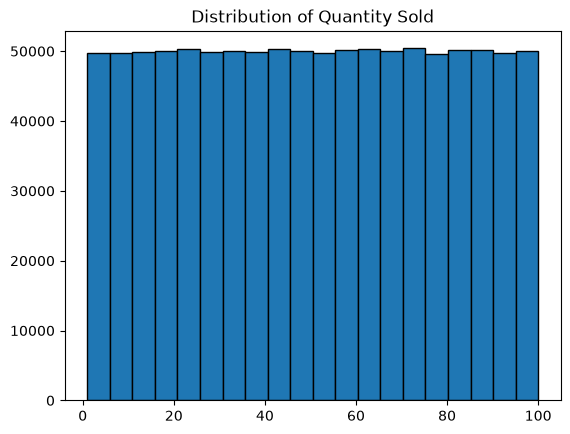

In [6]:
# visualize the distribution of 'Quantity Sold' as a histogram
plt.hist(df_pharmacy_sales["Quantity Sold"], bins=20, edgecolor="k")
plt.title("Distribution of Quantity Sold")
plt.show()

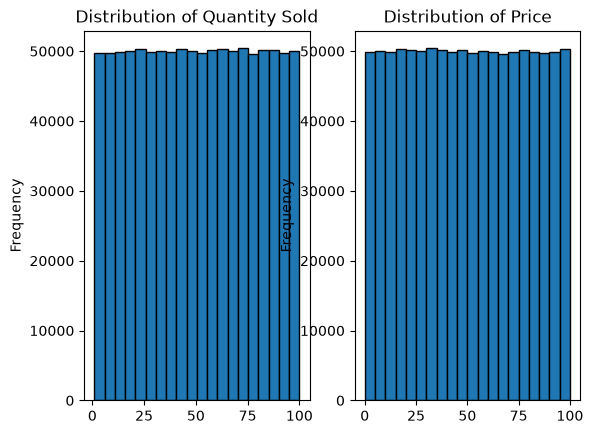

In [7]:
# create subplots using plt.subplot(nrows, ncols, index)
# each subplot takes the 'index' position on a grid with 'nrows' rows and 'ncols' columns
# 'index' starts at 1 in the upper left corner and increases to the right
plt.subplot(1, 2, 1)
df_pharmacy_sales["Quantity Sold"].plot.hist(bins=20, edgecolor="k")
plt.title("Distribution of Quantity Sold")

plt.subplot(1, 2, 2)
df_pharmacy_sales["Price"].plot.hist(bins=20, edgecolor="k")
plt.title("Distribution of Price")

plt.show()

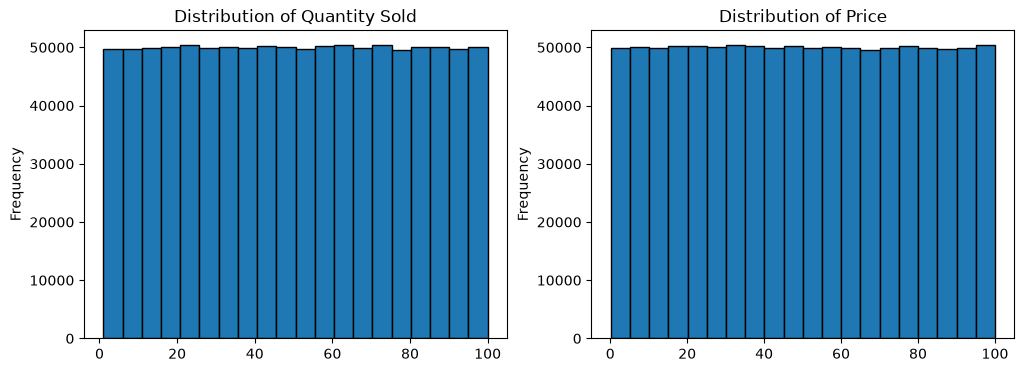

In [8]:
# improve the appearance of subplots by placing them inside a figure
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_pharmacy_sales["Quantity Sold"].plot.hist(bins=20, edgecolor="k")
plt.title("Distribution of Quantity Sold")

plt.subplot(1, 2, 2)
df_pharmacy_sales["Price"].plot.hist(bins=20, edgecolor="k")
plt.title("Distribution of Price")

plt.show()

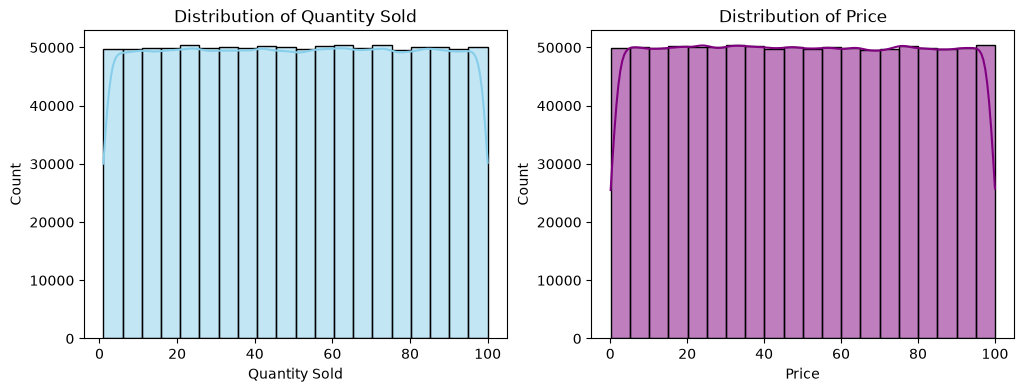

In [9]:
# create the same histograms using seaborn
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
sns.histplot(df_pharmacy_sales["Quantity Sold"], bins=20, kde=True, color="skyblue")
plt.title("Distribution of Quantity Sold")

plt.subplot(1, 2, 2)
sns.histplot(df_pharmacy_sales["Price"], bins=20, kde=True, color="purple")
plt.title("Distribution of Price")

plt.show()

## 02: Medication Class Analysis Pt. 1

In [ ]:
# medications can be classified based on the pharmacological class they belong to

In [10]:
# read a CSV file into a data frame
df_pharmacy_sales = pd.read_csv(input_folder_path+"demo_pharmacy_sales_data.csv")
df_pharmacy_sales

,Date Sold,Med_name,Med_class,Quantity Sold,Price
0,2021-05-07,Clotrimazole Topical Cream (2%),Antifungal,66,86.9
1,2021-08-09,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,15,22.9
2,2021-06-15,Methyltestosterone Tablet (10 mg),Androgen Hormone,5,5.9
3,2021-02-19,Buspirone Tablet (5 mg),Anxiolytic,89,55.7
4,2022-09-24,Hydrocodone/Acetaminophen Tablet (5/325 mg),Opioid Analgesic/Analgesic Combination,79,0.7
...,...,...,...,...,...
999995,2020-11-29,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,34,58.0
999996,2021-03-30,Fenoprofen Tablet (600 mg),Nonsteroidal Anti-Inflammatory Drug,12,98.3
999997,2020-04-17,Doxazosin Tablet (1 mg),Alpha-Blocker,83,10.3
999998,2021-12-08,Flumazenil Injection (0.1 mg/mL),Benzodiazepine Antagonist,1,23.9


In [11]:
# inspect the count of values in 'Med_name'
df_pharmacy_sales["Med_name"].value_counts()

Med_name
Tretinoin Topical Cream (0.025%)                     15027
Ketoconazole Topical Cream (2%)                      11008
Adapalene/Benzoyl Peroxide Topical Gel (0.1/2.5%)    10097
Triamcinolone Topical Ointment (0.1%)                10083
Clobetasol Topical Cream (0.05%)                      9984
                                                     ...  
Captopril Tablet (50 mg)                               939
Olopatadine Nasal Spray (665 mcg/spray)                938
Methylphenidate Tablet (10 mg)                         938
Lithium Carbonate Capsule (300 mg)                     920
Clindamycin Topical Lotion (1%)                        917
Name: count, Length: 279, dtype: int64

In [ ]:
# 'Med_name' features 279 unique medication names

In [12]:
# inspect the count of values in 'Med_class'
df_pharmacy_sales["Med_class"].value_counts()

Med_class
Nonsteroidal Anti-Inflammatory Drug                        82146
Phosphodiesterase Type 5 Inhibitor                         56294
Alpha-Blocker                                              52208
Anticonvulsant                                             49766
Beta-Blocker                                               40673
                                                           ...  
Norepinephrine Reuptake Inhibitor                            995
Melatonin Receptor Agonist                                   983
Cardiac Glycoside                                            981
Anticholinergic/Short-Acting Beta-2 Agonist Combination      977
Mood Stabilizer                                              920
Name: count, Length: 87, dtype: int64

In [ ]:
# 'Med_class' features 87 unique pharmacological classes

In [13]:
top_number = 20

In [14]:
# get the 'top_number' most present medication classes
# nlargest() returns the first n rows having the n highest values in column(s), sorted in descending order
top_classes = df_pharmacy_sales["Med_class"].value_counts().nlargest(top_number).index
top_classes

Index([' Nonsteroidal Anti-Inflammatory Drug',
       ' Phosphodiesterase Type 5 Inhibitor', ' Alpha-Blocker',
       ' Anticonvulsant', ' Beta-Blocker', ' Antifungal', ' Corticosteroid',
       ' Benzodiazepine', ' Low-Potency Corticosteroid',
       ' High-Potency Corticosteroid', ' Opioid Analgesic', ' Antibiotic',
       ' Inhaled Corticosteroid', ' 5-Alpha Reductase Inhibitor', ' Analgesic',
       ' Prostaglandin E1 Analog', ' Retinoid', ' Sympathomimetic',
       ' Vasodilator', ' Alpha-2 Agonist'],
      dtype='str', name='Med_class')

In [15]:
# create a data frame that only includes the 'top_number' most present medication classes
df_top_med_classes = df_pharmacy_sales[df_pharmacy_sales["Med_class"].isin(top_classes)]
df_top_med_classes

,Date Sold,Med_name,Med_class,Quantity Sold,Price
0,2021-05-07,Clotrimazole Topical Cream (2%),Antifungal,66,86.9
1,2021-08-09,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,15,22.9
6,2018-10-22,Norepinephrine Injection (2 mg/mL),Sympathomimetic,96,80.6
8,2022-05-19,Rofecoxib Tablet (25 mg),Nonsteroidal Anti-Inflammatory Drug,32,21.2
9,2019-07-21,Fluticasone Inhaler (50 mcg/actuation),Inhaled Corticosteroid,71,9.6
...,...,...,...,...,...
999992,2018-10-31,Carbamazepine Tablet (200 mg),Anticonvulsant,92,73.3
999995,2020-11-29,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,34,58.0
999996,2021-03-30,Fenoprofen Tablet (600 mg),Nonsteroidal Anti-Inflammatory Drug,12,98.3
999997,2020-04-17,Doxazosin Tablet (1 mg),Alpha-Blocker,83,10.3


In [ ]:
# this data frame includes 661970 entries

In [16]:
# get the total 'Quantity Sold' for the 'top_number' most present medication classes
# use 'ascending=False' in sort_values() to sort results based on decreasing values of 'Quantity Sold'
df_top_med_classes = df_top_med_classes.groupby("Med_class")["Quantity Sold"].sum().reset_index()
df_top_med_classes = df_top_med_classes.sort_values(by="Quantity Sold")
df_top_med_classes

,Med_class,Quantity Sold
1,Alpha-2 Agonist,802378
19,Vasodilator,973025
18,Sympathomimetic,1005189
17,Retinoid,1019449
16,Prostaglandin E1 Analog,1060112
3,Analgesic,1061008
0,5-Alpha Reductase Inhibitor,1101549
11,Inhaled Corticosteroid,1112097
4,Antibiotic,1259910
10,High-Potency Corticosteroid,1509454


## 03: Medication Class Analysis Pt. 2

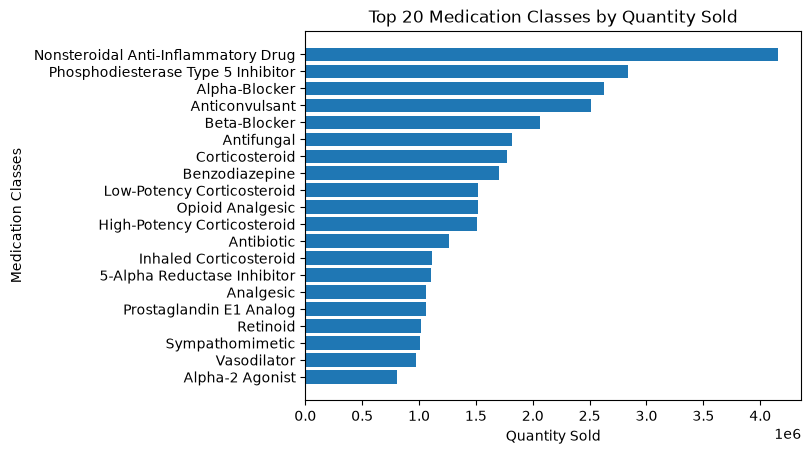

In [17]:
# visualize the 'top_number' most 'Quantity Sold' medication classes as an horizontal bar chart
plt.barh(df_top_med_classes["Med_class"], df_top_med_classes["Quantity Sold"])
plt.title(f"Top {top_number} Medication Classes by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Medication Classes")
plt.show()

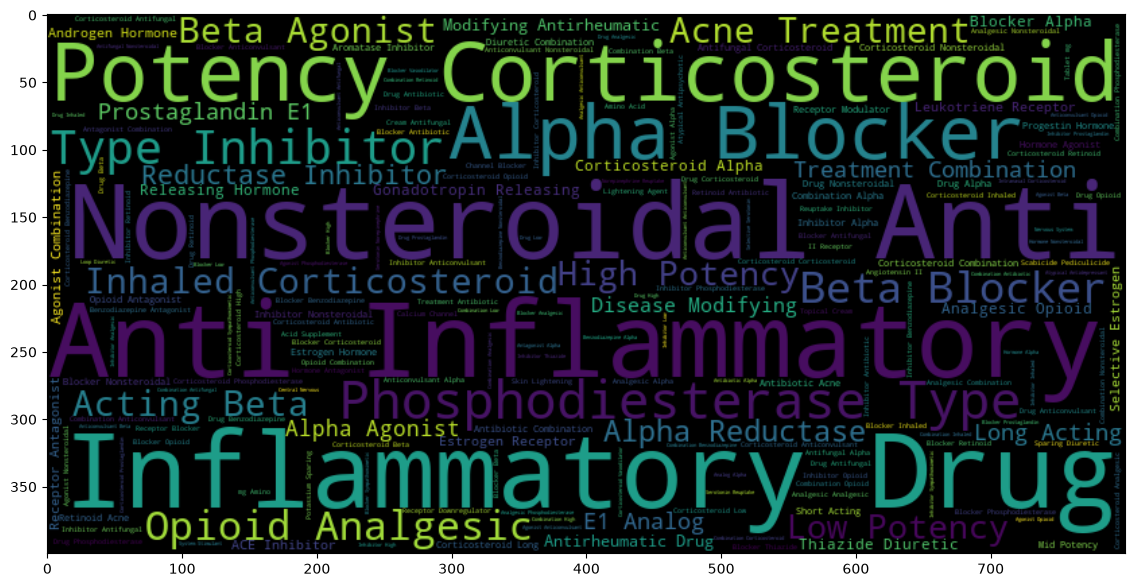

In [18]:
# visualize the 'top_number' 'Med_classes' by 'Quantity Sold' as a word cloud
med_class = df_pharmacy_sales["Med_class"].str.cat(sep='')
wordcloud = WordCloud(width=800, height=400).generate(med_class)
plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.show()

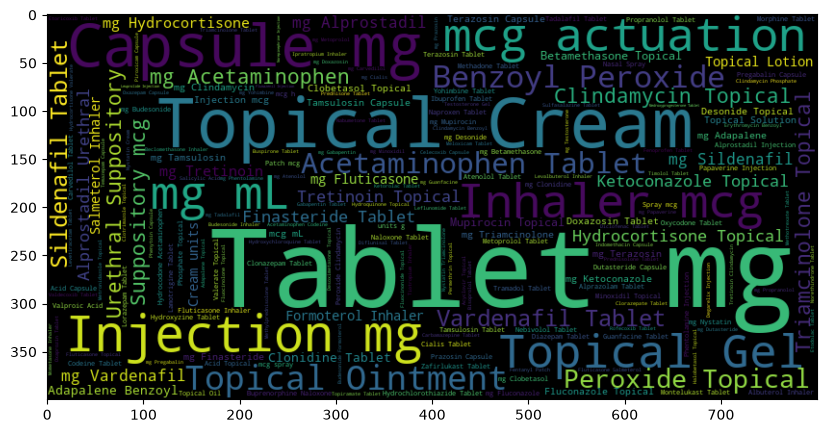

In [19]:
# visualize the 'top_number' 'Med_names' as a word cloud
med_names = df_pharmacy_sales["Med_name"].str.cat(sep='')
wordcloud = WordCloud(width=800, height=400).generate(med_names)
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.show()

## 04: Medication Demand Forecasting Pt. 1

In [ ]:
# the key goals of medication demand forecasting are...
# ... the prevention of life-saving medications to run out of stock...
# ... and the optimization of inventory to prevent waste

In [20]:
df_pharmacy_sales = pd.read_csv(input_folder_path+"demo_pharmacy_sales_data.csv")
df_pharmacy_sales

,Date Sold,Med_name,Med_class,Quantity Sold,Price
0,2021-05-07,Clotrimazole Topical Cream (2%),Antifungal,66,86.9
1,2021-08-09,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,15,22.9
2,2021-06-15,Methyltestosterone Tablet (10 mg),Androgen Hormone,5,5.9
3,2021-02-19,Buspirone Tablet (5 mg),Anxiolytic,89,55.7
4,2022-09-24,Hydrocodone/Acetaminophen Tablet (5/325 mg),Opioid Analgesic/Analgesic Combination,79,0.7
...,...,...,...,...,...
999995,2020-11-29,Alprostadil Urethral Suppository (125 mcg),Prostaglandin E1 Analog,34,58.0
999996,2021-03-30,Fenoprofen Tablet (600 mg),Nonsteroidal Anti-Inflammatory Drug,12,98.3
999997,2020-04-17,Doxazosin Tablet (1 mg),Alpha-Blocker,83,10.3
999998,2021-12-08,Flumazenil Injection (0.1 mg/mL),Benzodiazepine Antagonist,1,23.9


In [21]:
# for forecasting purposes, only 'Date Sold' and 'Quantity Sold' are needed
# in light of this, let's filter the data frame for these columns...
# ... as well as for a given 'Med_class' e.g., 'Anxiolytic'
df_prophet = df_pharmacy_sales[df_pharmacy_sales["Med_class"].str.contains("Anxiolytic")][["Date Sold", "Quantity Sold"]]
df_prophet = df_prophet.reset_index() # the data frame resulting from the line above still has the original indexes
df_prophet

,index,Date Sold,Quantity Sold
0,3,2021-02-19,89
1,122,2022-03-01,82
2,143,2020-08-11,17
3,327,2020-12-08,86
4,518,2019-03-31,70
...,...,...,...
9999,999594,2019-08-11,42
10000,999711,2020-05-16,71
10001,999772,2019-09-02,63
10002,999883,2019-09-09,38


In [22]:
# rename columns
df_prophet = df_prophet.rename(columns={"Date Sold": "ds", "Quantity Sold": "y"})
df_prophet

,index,ds,y
0,3,2021-02-19,89
1,122,2022-03-01,82
2,143,2020-08-11,17
3,327,2020-12-08,86
4,518,2019-03-31,70
...,...,...,...
9999,999594,2019-08-11,42
10000,999711,2020-05-16,71
10001,999772,2019-09-02,63
10002,999883,2019-09-09,38


In [23]:
type(df_prophet["ds"][0])

str

In [24]:
# dates are actually formatted as strings
# let's change it to datetime
df_prophet["ds"] = pd.to_datetime(df_prophet["ds"])
type(df_prophet["ds"][0])

pandas.Timestamp

In [25]:
# create a variable containing a Prophet object
model = Prophet()

In [26]:
# fit the model to the df_prophet dataframe
model.fit(df_prophet)

17:53:08 - cmdstanpy - INFO - Chain [1] start processing
17:53:10 - cmdstanpy - INFO - Chain [1] done processing


In [27]:
# create a variable named 'future', then ask the model to create a future dataframe over one year
future = model.make_future_dataframe(periods=365)

In [28]:
# create a variable named 'forecast', containing the model predicting 'future'
forecast = model.predict(future)

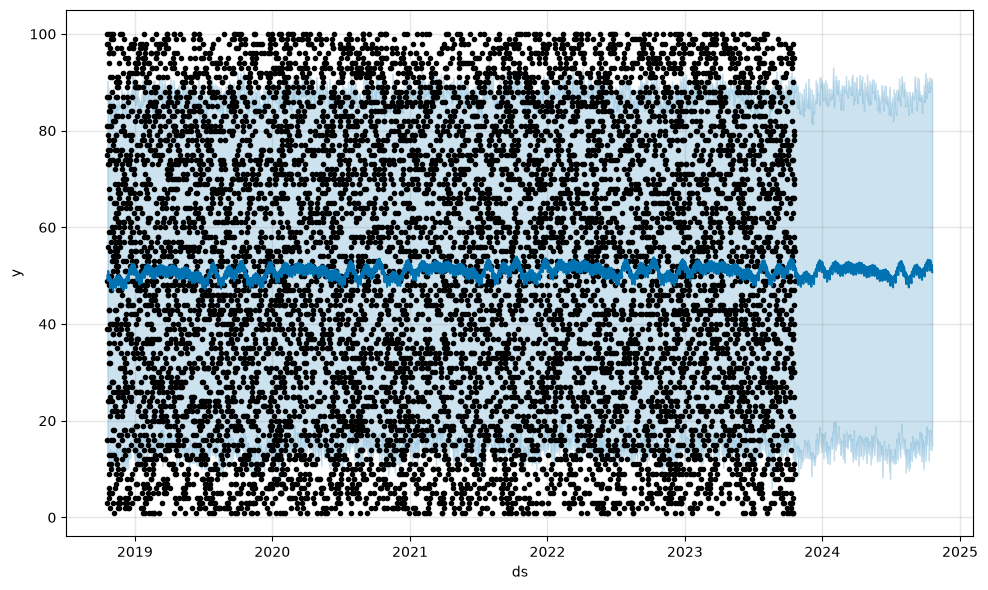

In [29]:
# create a figure for this prediction
fig = model.plot(forecast)
plt.show()

In [ ]:
# according to this prediction, the demand is going to be steady

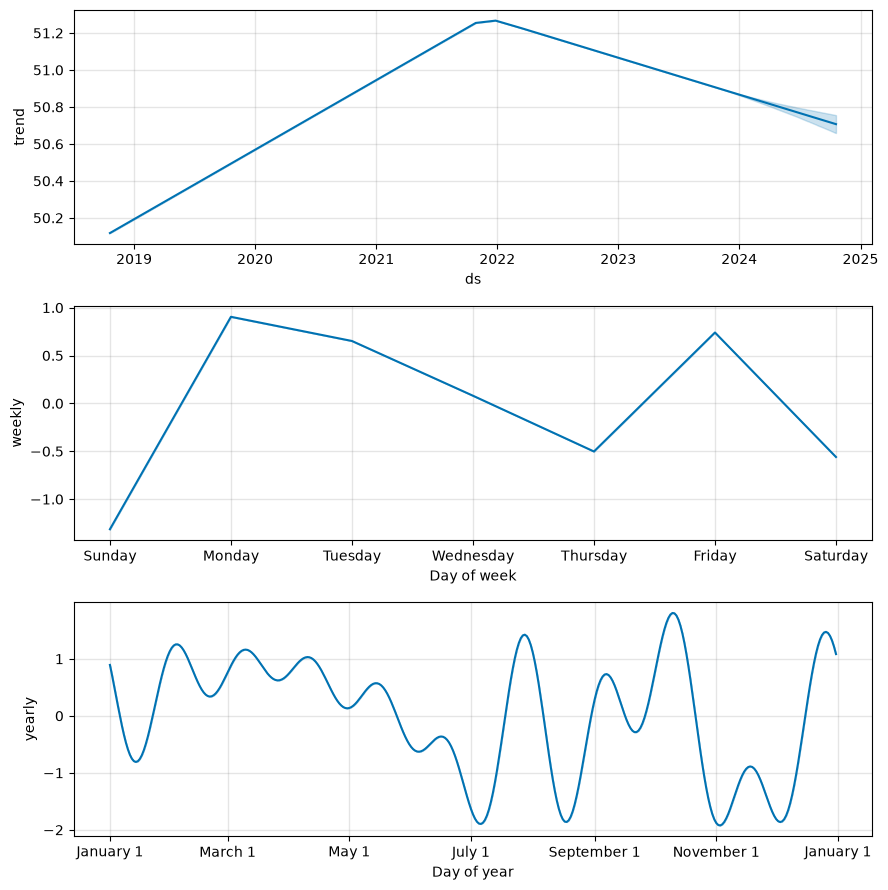

In [30]:
# plot individual components (i.e., predictions by year, day of the week, and month)
fig = model.plot_components(forecast)
plt.show()

## 05: Medication Demand Forecasting Pt. 2

In [35]:
# create a function that takes a data frame and a medication name/class...
# ... and returns the forecast
def medication_quantity_forecaster(df, med_class=None, med_name=None):
    if med_class:
        df_filtered = df[df["Med_class"].str.contains(med_class)]
    elif med_name:
        df_filtered = df[df["Med_name"].str.contains(med_name)]
    else:
        raise ValueError("Specify either med_name or med_class for filtering.")
    
    df_filtered = df_filtered[["Date Sold", "Quantity Sold"]].copy()
    df_filtered = df_filtered.reset_index()

    df_filtered = df_filtered.rename(columns={"Date Sold": "ds", "Quantity Sold": "y"})

    df_filtered["ds"] = pd.to_datetime(df_filtered["ds"])

    model = Prophet()
    model.fit(df_filtered)

    future = model.make_future_dataframe(periods=365)
    forecast = model.predict(future)

    fig1 = model.plot(forecast)
    plt.title(f"Medication Quantity Forecast ({med_class or med_name})")
    plt.xlabel("Date")
    plt.ylabel("Quantity Sold")
    plt.show()

    fig2 = model.plot_components(forecast)
    plt.show()

    return fig1, fig2

18:05:33 - cmdstanpy - INFO - Chain [1] start processing
18:05:35 - cmdstanpy - INFO - Chain [1] done processing


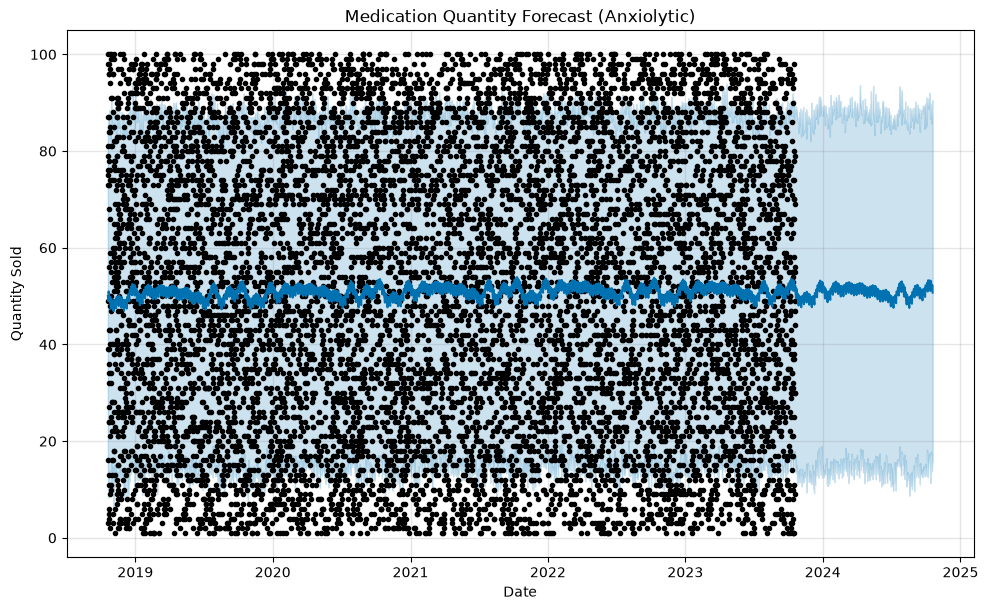

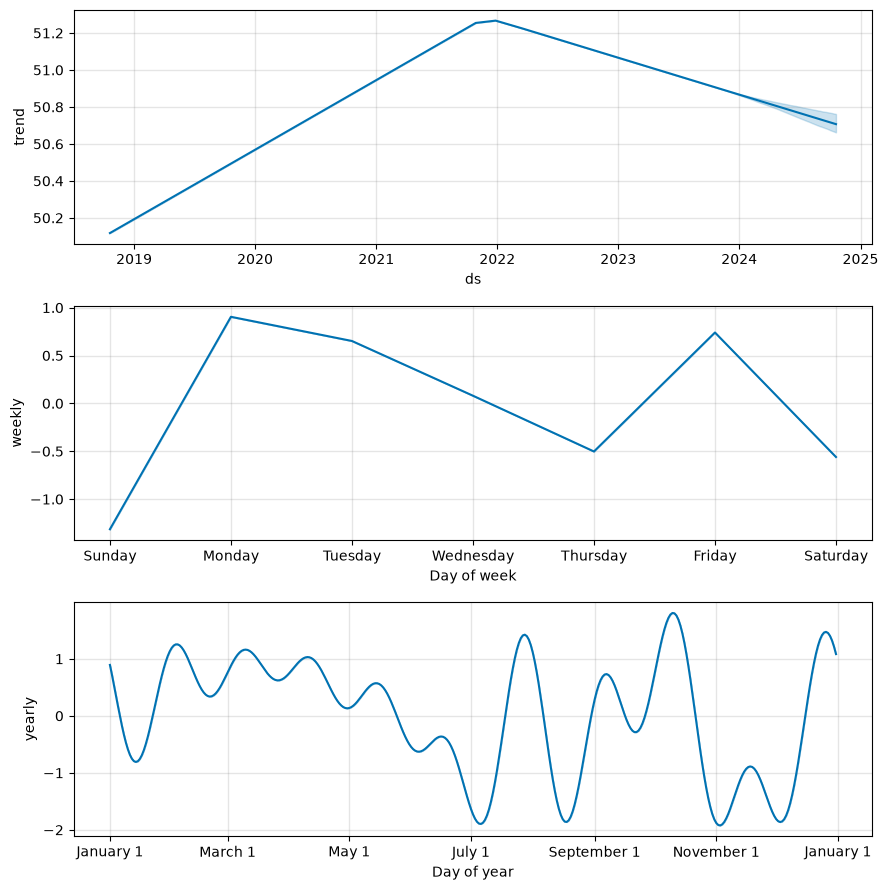

(<Figure size 1000x600 with 1 Axes>, <Figure size 900x900 with 3 Axes>)

In [36]:
medication_quantity_forecaster(df_pharmacy_sales, med_class="Anxiolytic")